# Optimal Transport in Latent Space

**Learning objectives**
1. See why Wasserstein distance remains meaningful when two latent supports do not overlap.
2. Visualize the exact transport plan between two latent point clouds.
3. Understand how Sinkhorn regularization speeds up OT by softening the transport plan.
4. See a key limitation: OT on empirical state distributions ignores temporal order in trajectories.

**Linked theory:** [research/07-optimal-transport-in-latent.md](../research/07-optimal-transport-in-latent.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.optimize import linear_sum_assignment
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})

def pairwise_sq_dists(x, y):
    diff = x[:, None, :] - y[None, :, :]
    return np.sum(diff ** 2, axis=-1)

def exact_ot_uniform(x, y):
    cost = pairwise_sq_dists(x, y)
    row_ind, col_ind = linear_sum_assignment(cost)
    plan = np.zeros_like(cost)
    plan[row_ind, col_ind] = 1.0 / len(row_ind)
    value = cost[row_ind, col_ind].mean()
    return value, plan, cost, row_ind, col_ind

def sinkhorn_uniform(x, y, epsilon=0.05, n_iter=400):
    cost = pairwise_sq_dists(x, y)
    n, m = cost.shape
    a = np.full(n, 1.0 / n)
    b = np.full(m, 1.0 / m)
    kernel = np.exp(-cost / epsilon)
    u = np.ones(n)
    v = np.ones(m)
    for _ in range(n_iter):
        u = a / (kernel @ v + 1e-12)
        v = b / (kernel.T @ u + 1e-12)
    plan = (u[:, None] * kernel) * v[None, :]
    value = np.sum(plan * cost)
    entropy = -np.sum(plan * np.log(plan + 1e-12))
    return value, plan, cost, entropy

def sinkhorn_divergence_uniform(x, y, epsilon=0.05, n_iter=400):
    ot_xy, _, _, _ = sinkhorn_uniform(x, y, epsilon=epsilon, n_iter=n_iter)
    ot_xx, _, _, _ = sinkhorn_uniform(x, x, epsilon=epsilon, n_iter=n_iter)
    ot_yy, _, _, _ = sinkhorn_uniform(y, y, epsilon=epsilon, n_iter=n_iter)
    return ot_xy - 0.5 * ot_xx - 0.5 * ot_yy

def wasserstein_1d_sorted(x, y):
    x_sorted = np.sort(x)
    y_sorted = np.sort(y)
    return np.mean(np.abs(x_sorted - y_sorted))

print('Setup complete.')

Setup complete.


## Experiment 1: Non-overlapping support

**Question:** Why is Wasserstein distance still informative when two latent distributions barely overlap?

We create two one-dimensional latent distributions that live around different regions of the line. We compare a histogram-based KL estimate with the 1-Wasserstein distance. The goal is to see that OT still measures a *meaningful geometric gap* even when support overlap is tiny.

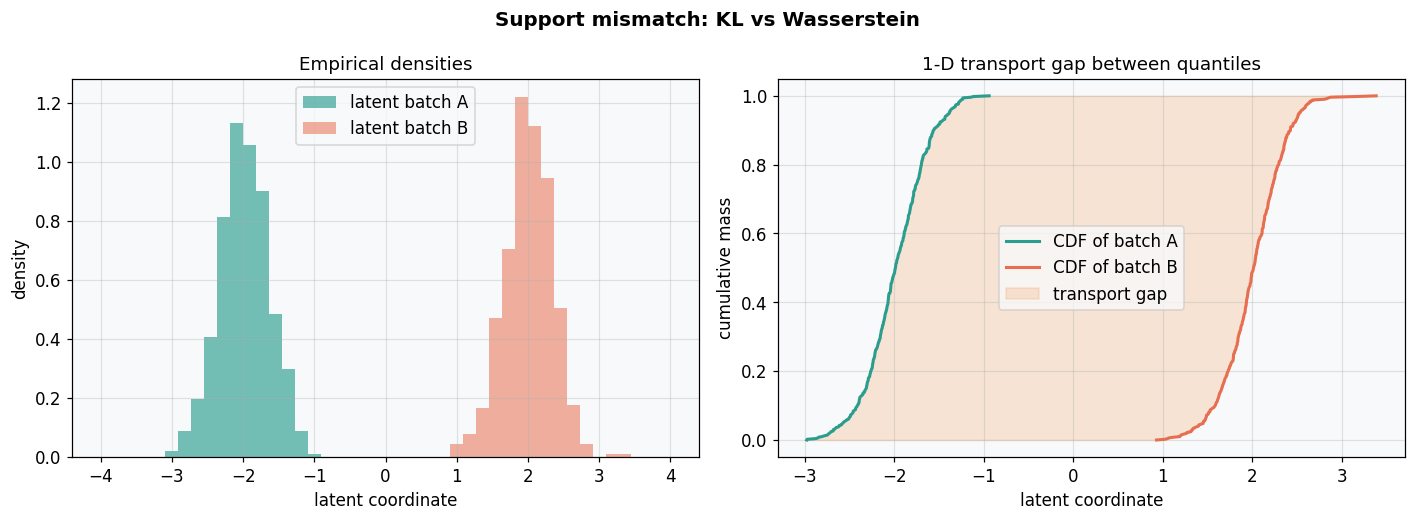

Histogram KL without smoothing: inf
Histogram KL with tiny smoothing: 13.448
1-Wasserstein distance: 3.990


In [2]:
np.random.seed(1)

x = np.random.normal(loc=-2.0, scale=0.35, size=500)
y = np.random.normal(loc=2.0, scale=0.35, size=500)

bins = np.linspace(-4.0, 4.0, 45)
hx, edges = np.histogram(x, bins=bins, density=True)
hy, _ = np.histogram(y, bins=bins, density=True)
widths = np.diff(edges)

mask = (hx > 0) & (hy > 0)
kl_without_smoothing = np.inf if np.any((hx > 0) & (hy == 0)) else np.sum(hx[mask] * np.log(hx[mask] / hy[mask]) * widths[mask])

eps = 1e-6
hx_s = hx + eps
hy_s = hy + eps
hx_s = hx_s / np.sum(hx_s * widths)
hy_s = hy_s / np.sum(hy_s * widths)
kl_smoothed = np.sum(hx_s * np.log(hx_s / hy_s) * widths)
w1 = wasserstein_1d_sorted(x, y)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
fig.suptitle('Support mismatch: KL vs Wasserstein', fontsize=13, fontweight='bold')

ax = axes[0]
ax.hist(x, bins=bins, density=True, alpha=0.65, label='latent batch A', color='#2a9d8f')
ax.hist(y, bins=bins, density=True, alpha=0.55, label='latent batch B', color='#e76f51')
ax.set_title('Empirical densities')
ax.set_xlabel('latent coordinate')
ax.set_ylabel('density')
ax.legend()

ax2 = axes[1]
xs = np.sort(x)
ys = np.sort(y)
p = np.linspace(0, 1, len(xs))
ax2.plot(xs, p, label='CDF of batch A', color='#2a9d8f', linewidth=2)
ax2.plot(ys, p, label='CDF of batch B', color='#e76f51', linewidth=2)
ax2.fill_betweenx(p, xs, ys, color='#f4a261', alpha=0.25, label='transport gap')
ax2.set_title('1-D transport gap between quantiles')
ax2.set_xlabel('latent coordinate')
ax2.set_ylabel('cumulative mass')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'Histogram KL without smoothing: {kl_without_smoothing}')
print(f'Histogram KL with tiny smoothing: {kl_smoothed:.3f}')
print(f'1-Wasserstein distance: {w1:.3f}')

### What you see

1. **What the plot shows:** The two empirical latent distributions sit in disjoint regions. The histogram overlap is almost zero, while the CDF panel shows a clear horizontal gap between matching quantiles.
2. **Why it looks this way:** KL compares density values at the same coordinates, so once one histogram assigns mass where the other assigns almost none, the ratio becomes unstable or infinite. Wasserstein instead asks how far mass must move, so it returns a finite value close to the actual translation between the two clouds.
3. **Key takeaway:** OT is useful in latent space precisely when two distributions are geometrically close but support-misaligned; KL can fail in exactly that regime.

## Experiment 2: Exact OT plan on two latent minibatches

**Question:** What does an optimal transport *plan* look like between two small latent point clouds?

We sample two equal-mass minibatches in 2-D latent space and solve the exact balanced OT problem under squared Euclidean cost. Because the batches are small and uniformly weighted, the plan becomes a crisp assignment that we can inspect visually.

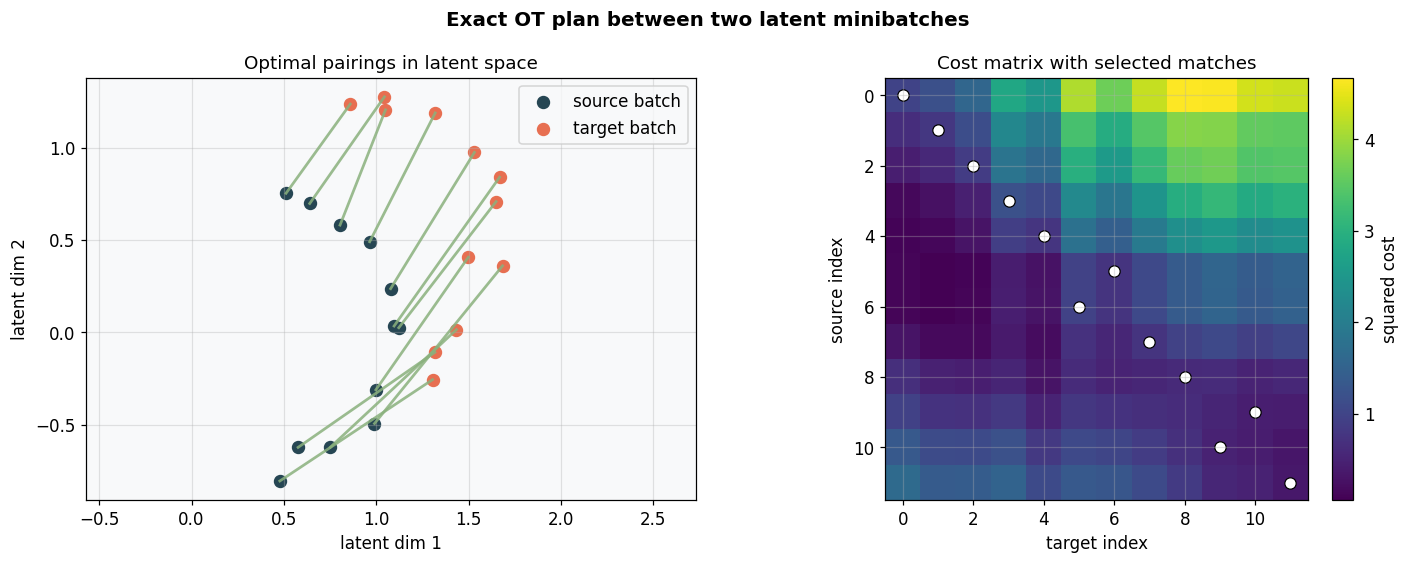

Average exact OT cost per transported particle: 0.7519
Number of matched pairs: 12


In [3]:
np.random.seed(2)

angles = np.linspace(-1.1, 1.1, 12)
source = np.column_stack([
    1.1 * np.cos(angles),
    0.9 * np.sin(angles)
])
source += 0.05 * np.random.randn(*source.shape)

rotation = np.array([[np.cos(0.35), -np.sin(0.35)], [np.sin(0.35), np.cos(0.35)]])
target = source @ rotation.T + np.array([0.6, 0.35])
target += 0.06 * np.random.randn(*target.shape)

exact_cost, exact_plan, exact_cost_matrix, row_ind, col_ind = exact_ot_uniform(source, target)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
fig.suptitle('Exact OT plan between two latent minibatches', fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(source[:, 0], source[:, 1], s=60, color='#264653', label='source batch')
ax.scatter(target[:, 0], target[:, 1], s=60, color='#e76f51', label='target batch')
for i, j in zip(row_ind, col_ind):
    ax.plot([source[i, 0], target[j, 0]], [source[i, 1], target[j, 1]], color='#8ab17d', linewidth=1.8, alpha=0.85)
ax.set_title('Optimal pairings in latent space')
ax.set_xlabel('latent dim 1')
ax.set_ylabel('latent dim 2')
ax.legend()
ax.axis('equal')

ax2 = axes[1]
image = ax2.imshow(exact_cost_matrix, cmap='viridis')
selected = np.argwhere(exact_plan > 0)
ax2.scatter(selected[:, 1], selected[:, 0], color='white', s=55, marker='o', edgecolors='black', linewidths=0.8)
ax2.set_title('Cost matrix with selected matches')
ax2.set_xlabel('target index')
ax2.set_ylabel('source index')
fig.colorbar(image, ax=ax2, fraction=0.046, pad=0.04, label='squared cost')

plt.tight_layout()
plt.show()

print(f'Average exact OT cost per transported particle: {exact_cost:.4f}')
print(f'Number of matched pairs: {len(row_ind)}')

### What you see

1. **What the plot shows:** The left panel draws the exact pairings chosen by OT between source and target latent points. The right panel shows the full cost matrix, with the selected assignment marked on top.
2. **Why it looks this way:** Because every point has equal mass and the two batches have the same size, the balanced OT solution collapses to a one-to-one matching that minimizes the total squared travel distance. Nearby points are paired whenever possible, but the plan is global: a locally cheap match can still be rejected if it blocks a better overall assignment.
3. **Key takeaway:** OT does not just output a scalar distance; it exposes the correspondence structure between two latent clouds, which is often the most informative part for debugging model behavior.

## Experiment 3: Sinkhorn regularization softens the plan

**Question:** What changes when we replace exact OT with entropically regularized OT?

We reuse two one-dimensional latent batches and compare the exact assignment with Sinkhorn plans at small and large regularization. The goal is to see the speed-for-bias trade-off directly in the transport matrix.

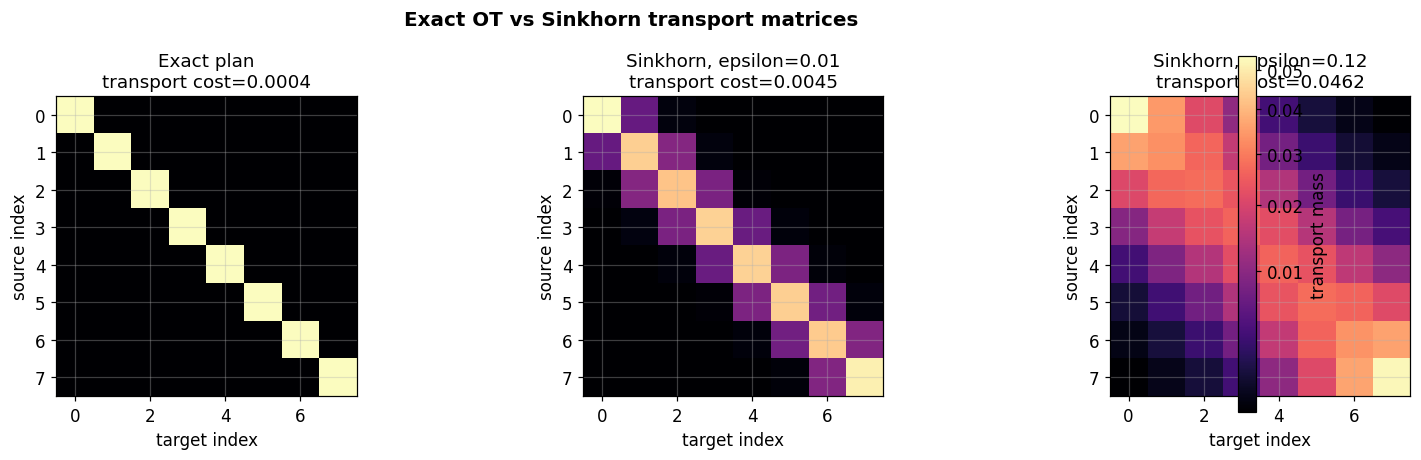

Exact OT cost: 0.0004
Sinkhorn cost, epsilon=0.01: 0.0045 | entropy=2.7491 | divergence=0.0004
Sinkhorn cost, epsilon=0.12: 0.0462 | entropy=3.7731 | divergence=0.0004


In [4]:
x_pts = np.linspace(0.05, 0.95, 8)[:, None]
y_pts = np.array([0.02, 0.18, 0.30, 0.43, 0.58, 0.71, 0.85, 0.98])[:, None]

exact_cost_1d, exact_plan_1d, cost_1d, _, _ = exact_ot_uniform(x_pts, y_pts)
small_cost, small_plan, _, small_entropy = sinkhorn_uniform(x_pts, y_pts, epsilon=0.01, n_iter=600)
large_cost, large_plan, _, large_entropy = sinkhorn_uniform(x_pts, y_pts, epsilon=0.12, n_iter=600)
small_div = sinkhorn_divergence_uniform(x_pts, y_pts, epsilon=0.01, n_iter=600)
large_div = sinkhorn_divergence_uniform(x_pts, y_pts, epsilon=0.12, n_iter=600)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))
fig.suptitle('Exact OT vs Sinkhorn transport matrices', fontsize=13, fontweight='bold')

plots = [
    ('Exact plan', exact_plan_1d, exact_cost_1d),
    ('Sinkhorn, epsilon=0.01', small_plan, small_cost),
    ('Sinkhorn, epsilon=0.12', large_plan, large_cost),
]

for ax, (title, plan, value) in zip(axes, plots):
    im = ax.imshow(plan, cmap='magma', norm=colors.PowerNorm(gamma=0.55))
    ax.set_title(f'{title}\ntransport cost={value:.4f}')
    ax.set_xlabel('target index')
    ax.set_ylabel('source index')

fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label='transport mass')
plt.tight_layout()
plt.show()

print(f'Exact OT cost: {exact_cost_1d:.4f}')
print(f'Sinkhorn cost, epsilon=0.01: {small_cost:.4f} | entropy={small_entropy:.4f} | divergence={small_div:.4f}')
print(f'Sinkhorn cost, epsilon=0.12: {large_cost:.4f} | entropy={large_entropy:.4f} | divergence={large_div:.4f}')

### What you see

1. **What the plot shows:** The exact OT matrix is almost permutation-like: mass sits on a very thin ridge. Small-epsilon Sinkhorn stays close to that ridge, while large-epsilon Sinkhorn spreads mass over many nearby matches.
2. **Why it looks this way:** Entropic regularization rewards high-entropy plans. That makes the optimization much easier numerically, but it also encourages each source particle to split its mass across multiple targets instead of committing to one sharp match. As epsilon grows, the plan becomes smoother and the transport cost is increasingly biased by the regularizer.
3. **Key takeaway:** Sinkhorn is the practical default for latent minibatches because it is fast and differentiable, but the resulting plan is a softened approximation, not the exact correspondence.

## Experiment 4: OT sees occupancy, not temporal order

**Question:** Why is Wasserstein distance alone not enough for comparing latent trajectories?

We build one trajectory and a time-reversed copy of the same trajectory. As *sets of visited latent states*, the two are identical. As *time-indexed sequences*, they are very different. This is exactly the gap between trajectory distribution metrics and true trajectory metrics.

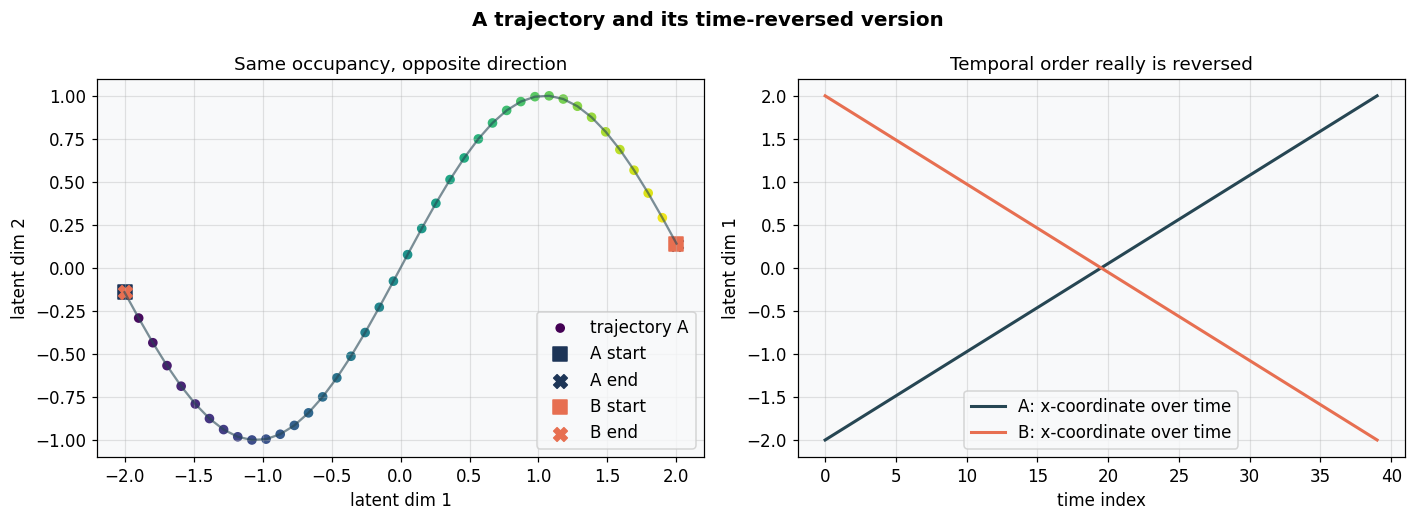

Exact OT cost between state sets: 0.00000000
Pathwise RMSE between ordered trajectories: 2.7657


In [5]:
t = np.linspace(-2.0, 2.0, 40)
traj_a = np.column_stack([t, np.sin(1.5 * t)])
traj_b = traj_a[::-1].copy()

traj_w2, _, _, _, _ = exact_ot_uniform(traj_a, traj_b)
pathwise_rmse = np.sqrt(np.mean(np.sum((traj_a - traj_b) ** 2, axis=1)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
fig.suptitle('A trajectory and its time-reversed version', fontsize=13, fontweight='bold')

colors_a = np.linspace(0, 1, len(traj_a))
colors_b = np.linspace(0, 1, len(traj_b))

ax = axes[0]
sc1 = ax.scatter(traj_a[:, 0], traj_a[:, 1], c=colors_a, cmap='viridis', s=28, label='trajectory A')
ax.plot(traj_a[:, 0], traj_a[:, 1], color='#264653', alpha=0.6)
ax.scatter(traj_a[0, 0], traj_a[0, 1], marker='s', s=80, color='#1d3557', label='A start')
ax.scatter(traj_a[-1, 0], traj_a[-1, 1], marker='X', s=80, color='#1d3557', label='A end')
ax.scatter(traj_b[0, 0], traj_b[0, 1], marker='s', s=80, color='#e76f51', label='B start')
ax.scatter(traj_b[-1, 0], traj_b[-1, 1], marker='X', s=80, color='#e76f51', label='B end')
ax.set_title('Same occupancy, opposite direction')
ax.set_xlabel('latent dim 1')
ax.set_ylabel('latent dim 2')
ax.legend(loc='lower right')

ax2 = axes[1]
ax2.plot(np.arange(len(traj_a)), traj_a[:, 0], label='A: x-coordinate over time', color='#264653', linewidth=2)
ax2.plot(np.arange(len(traj_b)), traj_b[:, 0], label='B: x-coordinate over time', color='#e76f51', linewidth=2)
ax2.set_title('Temporal order really is reversed')
ax2.set_xlabel('time index')
ax2.set_ylabel('latent dim 1')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'Exact OT cost between state sets: {traj_w2:.8f}')
print(f'Pathwise RMSE between ordered trajectories: {pathwise_rmse:.4f}')

### What you see

1. **What the plot shows:** Spatially, the two trajectories visit exactly the same latent points. Temporally, one runs through them in the reverse order, which is obvious in the time-index plot.
2. **Why it looks this way:** Balanced OT on empirical measures ignores timestamps; it only cares about how much mass sits at each location. Since the unordered state sets are identical, the optimal transport cost is essentially zero. A pathwise sequence metric, however, sees a large mismatch because point `t=0` in one trajectory corresponds to point `t=T` in the other.
3. **Key takeaway:** Wasserstein distance is a state-occupancy metric, not a full dynamics metric. For latent trajectories, OT should usually be combined with windowing, causality constraints, or sequence-aware distances.

## Summary / Key takeaways

- OT is valuable in latent space because it compares **distributions geometrically**, even when their supports barely overlap.
- The transport **plan** is often more informative than the scalar distance, because it reveals which latent regions are being matched.
- Sinkhorn regularization is the practical compromise for minibatch-scale OT: faster and differentiable, but biased toward softer matchings.
- For latent trajectories, plain Wasserstein sees **where** states were visited, not **when** they were visited.